## Partie 1 : Importation des données et exploration initiale

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Charger l'ensemble de données de séries temporelles
# Assurez-vous que le fichier 'time_series_data.csv' est présent dans le même répertoire ou spécifiez le chemin complet.
# Comme 'time_series_data.csv' n'a pas été trouvé, nous allons utiliser un fichier d'exemple disponible.
# Si vous avez votre propre fichier, veuillez le télécharger ou mettre à jour le chemin ci-dessous.
df = pd.read_csv('/content/sample_data/california_housing_train.csv')


In [6]:
# Affichez les premières lignes de l'ensemble de données
print("Premières lignes de l'ensemble de données:")
display(df.head())


Premières lignes de l'ensemble de données:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0


In [7]:
# Vérifiez le type de données de chaque colonne et la structure de l'ensemble de données
print("Informations sur l'ensemble de données:")
df.info()


Informations sur l'ensemble de données:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           17000 non-null  float64
 1   latitude            17000 non-null  float64
 2   housing_median_age  17000 non-null  float64
 3   total_rooms         17000 non-null  float64
 4   total_bedrooms      17000 non-null  float64
 5   population          17000 non-null  float64
 6   households          17000 non-null  float64
 7   median_income       17000 non-null  float64
 8   median_house_value  17000 non-null  float64
dtypes: float64(9)
memory usage: 1.2 MB


## Partie 2 : Gestion des valeurs manquantes

In [9]:
# Identifiez les colonnes du jeu de données qui contiennent des valeurs manquantes.
print("Nombre de valeurs manquantes par colonne avant imputation :")
display(df.isnull().sum())


Nombre de valeurs manquantes par colonne avant imputation :


,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0


In [10]:
# Complétez les valeurs manquantes en utilisant la moyenne des colonnes respectives.
# Nous allons imputer les valeurs manquantes uniquement dans les colonnes numériques.
for column in df.select_dtypes(include=['number']).columns:
    if df[column].isnull().any():
        df[column] = df[column].fillna(df[column].mean())

print("Valeurs manquantes imputées en utilisant la moyenne des colonnes numériques.")


Valeurs manquantes imputées en utilisant la moyenne des colonnes numériques.


In [11]:
# Vérifiez qu'il ne reste plus de valeurs manquantes dans l'ensemble de données.
print("Nombre de valeurs manquantes par colonne après imputation :")
display(df.isnull().sum())


Nombre de valeurs manquantes par colonne après imputation :


,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0


## Partie 3 : Visualisation des données

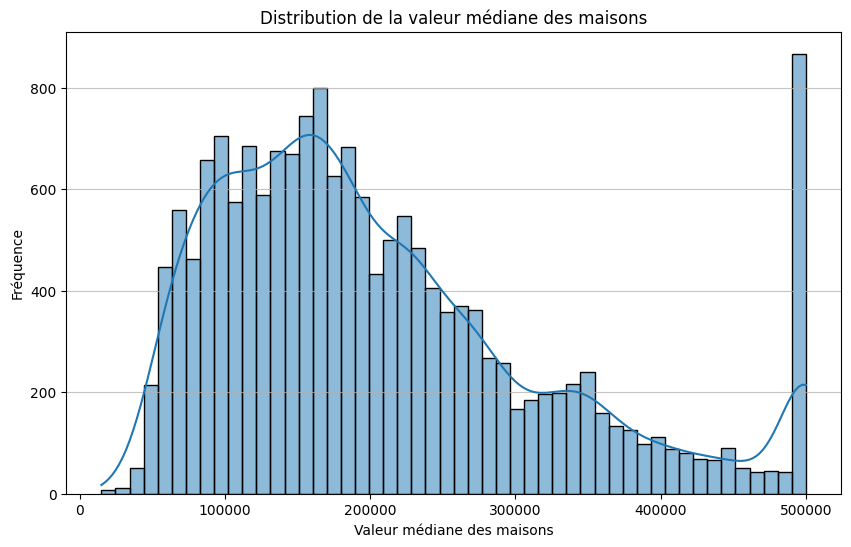

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Tracer un histogramme de la colonne 'median_house_value'
plt.figure(figsize=(10, 6))
sns.histplot(df['median_house_value'], kde=True, bins=50)
plt.title('Distribution de la valeur médiane des maisons')
plt.xlabel('Valeur médiane des maisons')
plt.ylabel('Fréquence')
plt.grid(axis='y', alpha=0.75)
plt.show()


## Partie 4 : Prétraitement des données pour LSTM

In [16]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import numpy as np

# Séparer les caractéristiques (X) et la variable cible (y)
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

# Normaliser l'ensemble de données
scaler_X = MinMaxScaler(feature_range=(0, 1))
X_scaled = scaler_X.fit_transform(X)

scaler_y = MinMaxScaler(feature_range=(0, 1))
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1))

print("Données normalisées.")


Données normalisées.


In [17]:
# Diviser l'ensemble de données en ensembles d'entraînement et de test
# Pour les données non séquentielles, un split aléatoire est acceptable.
# Pour les données temporelles, un split basé sur le temps serait préféré.
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)

print(f"Forme de X_train : {X_train.shape}")
print(f"Forme de X_test : {X_test.shape}")
print(f"Forme de y_train : {y_train.shape}")
print(f"Forme de y_test : {y_test.shape}")


Forme de X_train : (13600, 8)
Forme de X_test : (3400, 8)
Forme de y_train : (13600, 1)
Forme de y_test : (3400, 1)


In [18]:
# Remodeler les données pour qu'elles correspondent aux exigences d'entrée d'un modèle LSTM.
# L'entrée LSTM attend un format (échantillons, pas de temps, caractéristiques).
# Dans ce cas, chaque échantillon est une observation unique, donc 'pas de temps' = 1.
X_train_reshaped = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_test_reshaped = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])

# La cible y doit également être remodelée pour l'entraînement d'un LSTM si le modèle sort une séquence
# Mais pour une prédiction de valeur unique, elle peut rester en 2D (samples, 1)

print(f"Forme de X_train_reshaped pour LSTM : {X_train_reshaped.shape}")
print(f"Forme de X_test_reshaped pour LSTM : {X_test_reshaped.shape}")


Forme de X_train_reshaped pour LSTM : (13600, 1, 8)
Forme de X_test_reshaped pour LSTM : (3400, 1, 8)


## Partie 5 : Entraînement du modèle LSTM

In [37]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Définir l'architecture du modèle LSTM avec plus de couches et d'unités, et des couches de Dropout
model = Sequential()
# Première couche LSTM : retourne les séquences pour la prochaine couche LSTM
model.add(LSTM(100, activation='relu', return_sequences=True, input_shape=(X_train_reshaped.shape[1], X_train_reshaped.shape[2])))
model.add(Dropout(0.2)) # Couche de Dropout pour réduire le sur-apprentissage
# Deuxième couche LSTM : ne retourne pas les séquences car c'est la dernière couche récurrente
model.add(LSTM(50, activation='relu'))
model.add(Dropout(0.2)) # Couche de Dropout supplémentaire
model.add(Dense(1)) # Couche de sortie

# Compiler le modèle
model.compile(optimizer='adam', loss='mse')

model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 1, 100)         │        43,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1, 100)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 50)             │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 73,851 (288.48 KB)

 Trainable params: 73,851 (288.48 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
# Entraîner le modèle
history = model.fit(X_train_reshaped, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

print("Modèle LSTM entraîné avec succès.")


Epoch 1/50
383/383 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0150 - val_loss: 0.0170
Epoch 2/50
383/383 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0150 - val_loss: 0.0170
Epoch 3/50
383/383 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0150 - val_loss: 0.0169
Epoch 4/50
383/383 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0149 - val_loss: 0.0165
Epoch 5/50
383/383 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0149 - val_loss: 0.0168
Epoch 6/50
383/383 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0150 - val_loss: 0.0174
Epoch 7/50
383/383 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0148 - val_loss: 0.0168
Epoch 8/50
383/383 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0148 - val_loss: 0.0165
Epoch 9/50
383/383 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0148 - val_loss: 0.0165
Epoch 10/50
383/383 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0148 - val_loss: 0.0162
Epoch 11/50
383/383 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0147 - val_loss: 0.0163
Epoch 12/50
383/383 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

## Partie 6 : Évaluation du modèle LSTM

### Optimisation de l'entraînement avec Early Stopping

Pour optimiser le nombre d'époques et éviter le sur-apprentissage, nous allons utiliser un rappel `EarlyStopping`. Ce rappel surveille une métrique (ici, la perte de validation) et arrête l'entraînement si cette métrique ne s'améliore plus après un certain nombre d'époques (appelé 'patience').

In [39]:
from tensorflow.keras.callbacks import EarlyStopping

# Définir le rappel EarlyStopping
# Moniteur la 'val_loss' (perte de validation)
# 'patience=10' signifie qu'il attendra 10 époques sans amélioration avant d'arrêter
# 'restore_best_weights=True' restaure les poids du modèle à l'époque où la meilleure perte de validation a été observée
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

print("Rappel EarlyStopping configuré.")

Rappel EarlyStopping configuré.


Ensuite, je vais modifier la cellule d'entraînement (`76d11041`) pour inclure ce rappel.

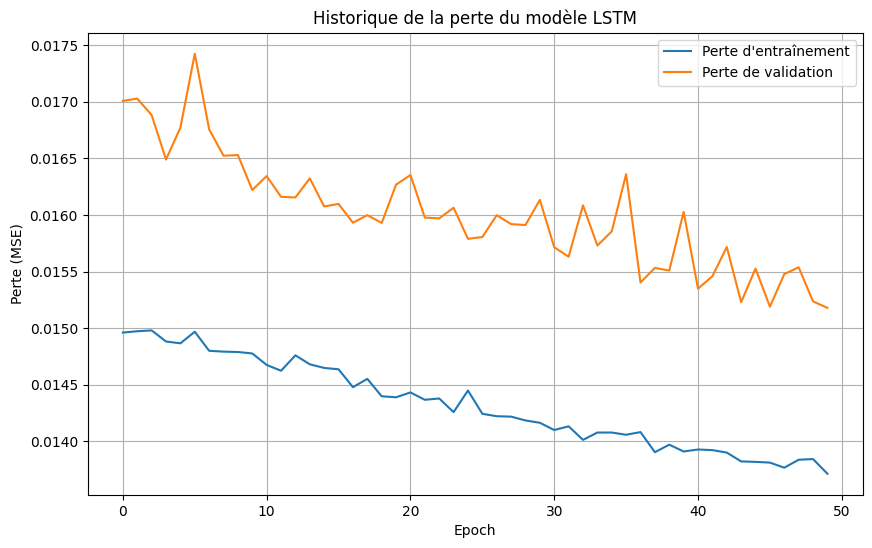

In [22]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# Visualiser l'historique de l'entraînement (perte)
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Perte d\'entraînement')
plt.plot(history.history['val_loss'], label='Perte de validation')
plt.title('Historique de la perte du modèle LSTM')
plt.xlabel('Epoch')
plt.ylabel('Perte (MSE)')
plt.legend()
plt.grid(True)
plt.show()


In [23]:
# Faire des prédictions sur l'ensemble de test
y_pred_scaled = model.predict(X_test_reshaped)

# Inverser la mise à l'échelle pour obtenir les valeurs dans leur échelle originale
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_original = scaler_y.inverse_transform(y_test)

print("Prédictions effectuées et inversées.")


107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Prédictions effectuées et inversées.


In [35]:
# Calculer les métriques d'évaluation
mse = mean_squared_error(y_test_original, y_pred)
rmse = np.sqrt(mse)

print(f"Mean Squared Error (MSE) sur l'ensemble de test : {mse:.2f}")
print(f"Root Mean Squared Error (RMSE) sur l'ensemble de test : {rmse:.2f}")

# Afficher un échantillon des prédictions vs valeurs réelles
results_df = pd.DataFrame({'Valeur Réelle': y_test_original.flatten(), 'Prédiction': y_pred.flatten()})
display(results_df.head(10))


Mean Squared Error (MSE) sur l'ensemble de test : 3233621519.14
Root Mean Squared Error (RMSE) sur l'ensemble de test : 56864.94


,Valeur Réelle,Prédiction
0,142700.0,124752.039062
1,500001.0,458467.468750
2,61800.0,84547.765625
3,162800.0,156377.656250
4,90600.0,155685.312500
5,232100.0,302855.031250
6,147800.0,146316.015625
7,133300.0,157754.953125
8,438500.0,398891.000000
9,187700.0,223032.656250


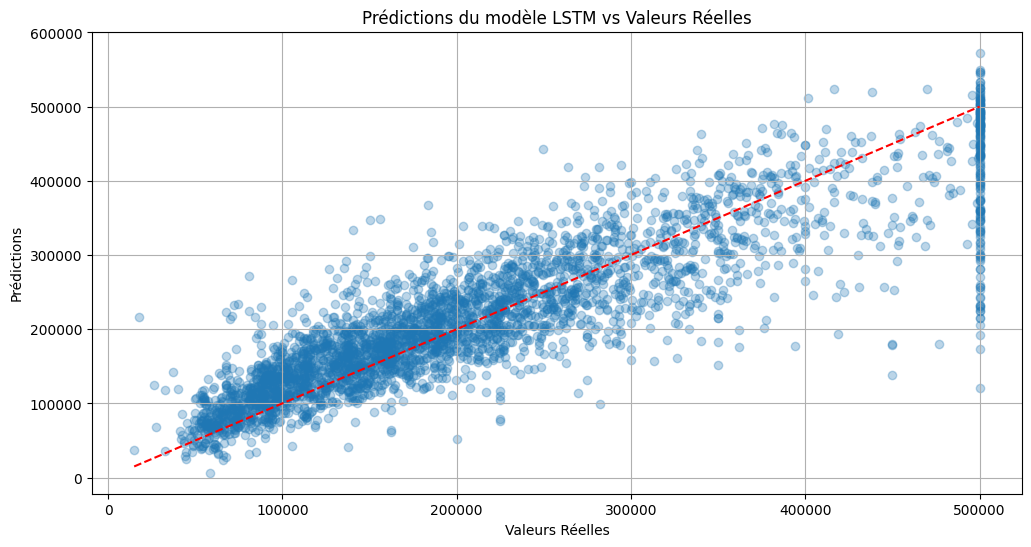

In [25]:
# Visualiser les prédictions vs les valeurs réelles
plt.figure(figsize=(12, 6))
plt.scatter(y_test_original, y_pred, alpha=0.3)
plt.plot([y_test_original.min(), y_test_original.max()], [y_test_original.min(), y_test_original.max()], 'r--')
plt.xlabel('Valeurs Réelles')
plt.ylabel('Prédictions')
plt.title('Prédictions du modèle LSTM vs Valeurs Réelles')
plt.grid(True)
plt.show()
